# Algorithme des plus proches voisins

knn : k nearest neighbors

## Génération de données d'exemple

Dans un premier exemple les points au dessus de la diagonale sont bleus et ceux en dessous sont rouges.
On va chercher à classer un nouveau point de couleur indéterminée.


Génération de 10 points de chaque couleur:

In [1]:
import random
random.seed(42)

n = 10  # Nombre de points par couleur
points_bleus = []
points_rouges = []
while len(points_bleus)!=n or len(points_rouges)!=n:
    x = random.randint(0,100)
    y = random.randint(0,100)
    if y >= x and len(points_bleus) < n:
        points_bleus.append((x,y))
    elif y < x and len(points_rouges) < n:
        points_rouges.append((x,y))

## Visualisation


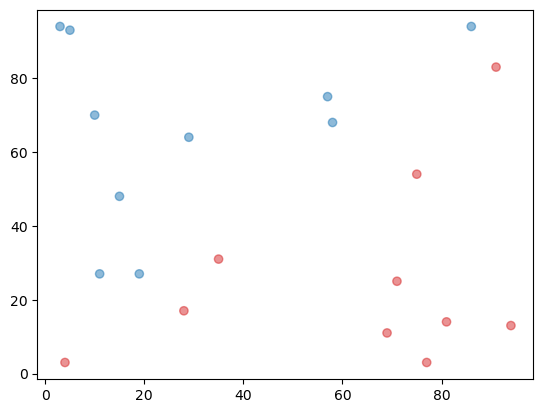

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# points_bleus puis points_rouges

abscisses = []
ordonnées = []
couleurs = []

for x,y in points_bleus:
    abscisses.append(x)
    ordonnées.append(y)
    couleurs.append('tab:blue')
for x,y in points_rouges:
    abscisses.append(x)
    ordonnées.append(y)
    couleurs.append('tab:red')

plt.scatter(abscisses, ordonnées, c=couleurs, alpha=0.5)
plt.show()

## Classification d'un nouveau point pris au hasard


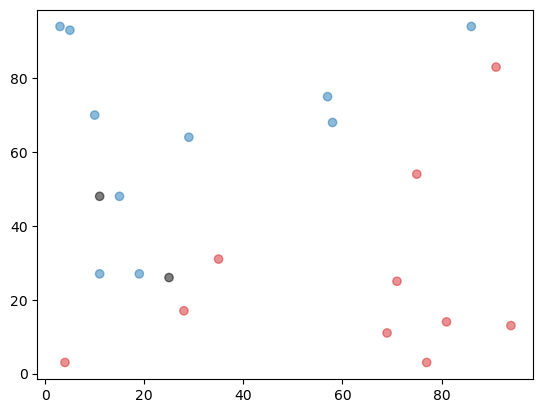

In [3]:
# Visualisation du jeu de données et des points que l'on cherche à classer (ici représentés en vert)
abscisses.append(11)
ordonnées.append(48)
abscisses.append(25)
ordonnées.append(26)
couleurs.append('black')
couleurs.append('black')
plt.scatter(abscisses, ordonnées, c=couleurs, alpha=0.5)
plt.show()

## Etapes de l'algorithme

1. Calcul de l'ensemble des distances du nouveau point indéterminé $B$ aux points du jeu de données initial ($A_i$) 
$$ L_2(A_i,B)$$
2. On choisit les k plus proches points au sens de la distance choisie.
3. On associe notre point indéterminée à la couleur la plus fréquente, parmis ces voisins.

## Normalisation

### Normalisation: motivation

Création d'un nouveau jeu de données d'exemple

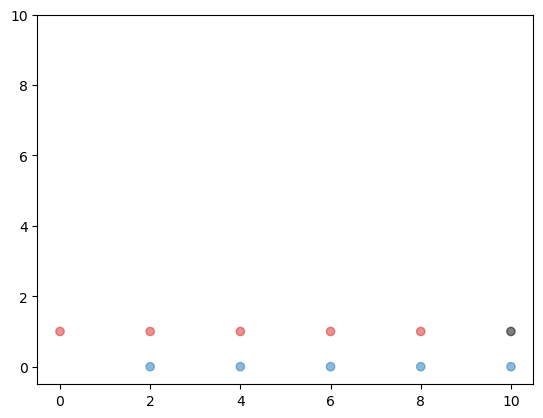

In [4]:
from collections import namedtuple
import matplotlib.pyplot as plt

Point = namedtuple('Point', 'x_1 x_2')
points_bleus = [Point(x_1, 0) for x_1 in range(2,12,2)]
points_rouges = [Point(x_1, 1) for x_1 in range(0,10,2)]

points = points_bleus + points_rouges
couleurs = ['bleu']*len(points_bleus) + ['rouge']*len(points_rouges)


abscisses  = [point.x_1 for point in points]
ordonnées = [point.x_2 for point in points]

point_inconnu = Point(10, 1)

colors = []
for c in couleurs:
    if c == 'bleu':
        colors.append('tab:blue')
    else:
        colors.append('tab:red')

# point_inconnu
abscisses.append(point_inconnu.x_1)
ordonnées.append(point_inconnu.x_2)
colors.append('black')

plt.ylim(-0.5, 10)
plt.scatter(abscisses, ordonnées, c=colors, alpha=0.5)
plt.show()

### Moyenne, variance et écart type

Pour l'ensemble de n valeurs `x = [x_1, ..., x_n ]`, on définit:
- la moyenne (mean):
$$\overline{x} = \mu = \frac{1}{n} \sum_{i=1}^{n}x_{i}$$
- La variance qui est une mesure de la dispersion de l'échantillon, c'est la moyenne des carrés des distances à la moyenne de l'échantillon.
$$Var(x)=\sigma^2=\frac{1}{n} \sum_{i=1}^{n}(x_{i}-\mu)^2$$
- l'écart type (standard deviation) 
$$\sigma=\sqrt{Var(x)}=\sqrt{\frac{1}{n} \sum_{i=1}^{n}(x_{i}-\overline{x})^2}$$

### Normalisation standard

Pour l'ensemble de n valeurs $x = [x_1, ..., x_n ]$, on définit:
$$z_{i} = \frac{x_{i}-\mu}{\sigma}$$

On utilise `z`à la place de `x`

On fait le même procédé sur chacun des axes

In [5]:
from statistics import mean, stdev
x_1 = [point.x_1 for point in points]
z1 = [(x_1_i - mean(x_1))/stdev(x_1) for x_1_i in x_1]
x_2 = [point.x_2 for point in points]
z2 = [(x_2_i - mean(x_2))/stdev(x_2) for x_2_i in x_2]

In [6]:
# valeurs de moyennes et d'écarts types reprises pour la modification des coordonnées du point inconnu
z1_inconnu = (point_inconnu.x_1 - mean(x_1))/stdev(x_1)
z2_inconnu = (point_inconnu.x_2 - mean(x_2))/stdev(x_2)

# Pour l'affichage
z1.append(z1_inconnu)
z2.append(z2_inconnu)

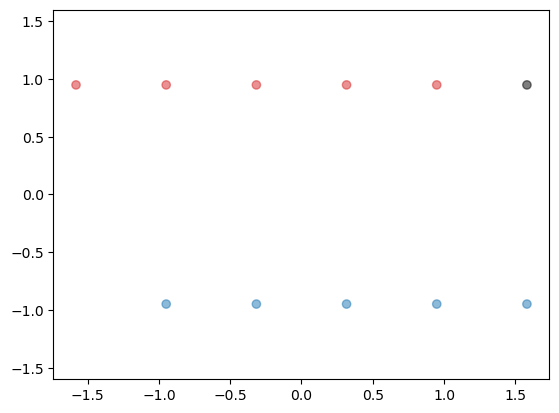

In [7]:
colors = []
for c in couleurs:
    if c == 'bleu':
        colors.append('tab:blue')
    else:
        colors.append('tab:red')
colors.append('black')

plt.ylim(-1.6, 1.6)
plt.scatter(z1, z2, c=colors, alpha=0.5)
plt.show()

## Utilisation de la fonction scikit learn

```text
KNeighborsClassifier

class sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)
[source]

    Classifier implementing the k-nearest neighbors vote.
```


In [8]:
import pandas as pd
from collections import namedtuple

Point = namedtuple('Point', 'x_1 x_2')

points_bleus = [Point(x_1, 0) for x_1 in range(2,12,2)]
points_rouges = [Point(x_1, 1) for x_1 in range(0,10,2)]

points = points_bleus + points_rouges
couleurs = ['bleu']*len(points_bleus) + ['rouge']*len(points_rouges)

data = pd.DataFrame({'abscisse' : [point.x_1 for point in points],
                     'ordonnée' : [point.x_2 for point in points],
                     'couleur' : couleurs})
data

# observation // individu
# X : caractéristiques (features), ici [abscisse, ordonnée], [x_1, x_2]
# y : classe, cible ici couleur

,abscisse,ordonnée,couleur
0,2,0,bleu
1,4,0,bleu
2,6,0,bleu
3,8,0,bleu
4,10,0,bleu
5,0,1,rouge
6,2,1,rouge
7,4,1,rouge
8,6,1,rouge
9,8,1,rouge


In [9]:
# Scikit-learn travaille avec des valeurs numériques
# Notre algorithme quant à lui autorise des valeurs textuelles pour y
[c=='bleu' for c in couleurs]

[True, True, True, True, True, False, False, False, False, False]

In [10]:
data = pd.DataFrame({'x_1' : [point.x_1 for point in points],
                     'x_2' : [point.x_2 for point in points],
                     'y' : [int(c=='bleu') for c in couleurs]})
data

,x_1,x_2,y
0,2,0,1
1,4,0,1
2,6,0,1
3,8,0,1
4,10,0,1
5,0,1,0
6,2,1,0
7,4,1,0
8,6,1,0
9,8,1,0


In [11]:
# X
X = pd.DataFrame({'x_1' : [point.x_1 for point in points],
                  'x_2' : [point.x_2 for point in points]})
print(X.to_string(index=False))

 x_1  x_2
   2    0
   4    0
   6    0
   8    0
  10    0
   0    1
   2    1
   4    1
   6    1
   8    1


$$
X=
\begin{bmatrix}
2 & 0\\ 
4 & 0\\ 
6 & 0\\ 
\vdots & \vdots \\ 
8 & 1\\ 
\end{bmatrix}
$$

In [12]:
# y
y = pd.DataFrame({'y' : [int(c=='bleu') for c in couleurs]})
print(y.to_string(index=False))

 y
 1
 1
 1
 1
 1
 0
 0
 0
 0
 0


$$
y=
\begin{bmatrix}
1\\ 
1\\ 
1\\ 
\vdots \\ 
0\\ 
\end{bmatrix}
$$

In [13]:
point_inconnu = Point(10, 1)


### Prédiction sans normalisation

On utilise `KNeighborsClassifier` avec $k=1$.

In [14]:
from sklearn.neighbors import KNeighborsClassifier

# Création du modèle pour k=1
knn = KNeighborsClassifier(n_neighbors=1)

# Entraînement du modèle
# On utilise y.values.ravel() pour éviter un avertissement de scikit-learn
knn.fit(X, y.values.ravel())

# Mise au format DataFrame pour le point inconnu afin de respecter le format de X
X_inconnu = pd.DataFrame({'x_1': [point_inconnu.x_1], 'x_2': [point_inconnu.x_2]})

# Prédiction
pred_sans_norm = knn.predict(X_inconnu)

couleur_pred = 'bleu' if pred_sans_norm[0] == 1 else 'rouge'
print(f"Prédiction SANS normalisation : le point {point_inconnu} est classé comme {couleur_pred}.")


Prédiction SANS normalisation : le point Point(x_1=10, x_2=1) est classé comme bleu.


**Explication :** Sans normalisation, l'algorithme classe le point (10, 1) en "bleu". En effet, la distance au point bleu (10, 0) est de $1$, alors que la distance au point rouge le plus proche (8, 1) est de $2$. L'axe des abscisses (qui va de 0 à 10) écrase complètement l'axe des ordonnées (qui va de 0 à 1).

### Prédiction avec normalisation (StandardScaler)

Nous allons maintenant utiliser `StandardScaler` de `scikit-learn` pour centrer et réduire nos données, de la même manière que la "Normalisation standard" expliquée plus haut.

In [15]:
from sklearn.preprocessing import StandardScaler

# Initialisation du scaler
scaler = StandardScaler()

# On calcule la moyenne et l'écart-type sur X, et on transforme X
X_scaled = scaler.fit_transform(X)

# On applique LA MÊME transformation au point inconnu
X_inconnu_scaled = scaler.transform(X_inconnu)


Maintenant, relançons notre algorithme des plus proches voisins sur ces données normalisées.

In [16]:
# Création d'un nouveau modèle
knn_norm = KNeighborsClassifier(n_neighbors=1)

# Entraînement sur les données normalisées
knn_norm.fit(X_scaled, y.values.ravel())

# Prédiction sur le point inconnu normalisé
pred_avec_norm = knn_norm.predict(X_inconnu_scaled)

couleur_pred_norm = 'bleu' if pred_avec_norm[0] == 1 else 'rouge'
print(f"Prédiction AVEC normalisation : le point {point_inconnu} est classé comme {couleur_pred_norm}.")


Prédiction AVEC normalisation : le point Point(x_1=10, x_2=1) est classé comme rouge.


**Conclusion :** Avec la normalisation, l'algorithme classe le point en "rouge" (ce qui est logiquement ce que l'on attend puisque tous les points rouges sont sur la ligne $x_2=1$). La normalisation a permis de redonner la même importance à l'axe des ordonnées qu'à l'axe des abscisses !

## Références

[StatQuest: K-nearest neighbors, Clearly Explained](https://www.youtube.com/watch?v=HVXime0nQeI)

[Introduction to Statistical Learning with applications in Python: Logistic Regression, LDA, QDA, and KNN](https://islp.readthedocs.io/en/latest/labs/Ch04-classification-lab.html)
